In [1]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from astropy.io import fits
from astropy.table import Table
import sys

In [2]:
# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

#import strucfunc                   
import strucfunc
import fit_structure_function
import ci_results_compiler
import bfunc
import bplot

# Posdoc

In [3]:
# Parameters
#name = "KPNO-M42-H-bin0"
fits_path = "fits_ready/KPNO-M42-H-bin0.fits"

In [4]:
# Loading obs
hdul = fits.open(fits_path)
hdr = hdul[0].header
print(hdul.info())
print(hdr)
sb_post = hdul['MOM0'].data.astype(float)
vv_post = hdul['MOM1'].data.astype(float)
hdul.close()

Filename: fits_ready/KPNO-M42-H-bin0.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      23   ()      
  1  MOM0          1 ImageHDU         8   (356, 514)   float64   
  2  MOM1          1 ImageHDU         8   (356, 514)   float64   
  3  MASK          1 ImageHDU         8   (356, 514)   uint8   
  4  TABLE         1 BinTableHDU     23   55R x 7C   [D, D, D, D, K, D, D]   
  5  PARAMETERS    1 BinTableHDU     19   3R x 5C   [D, D, D, D, D]   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  FILE    = 'KPech-Orion-H-m'    / Fits file name                                 NAME_ID = 'KPNO-M42-H-bin0'    / pipeline identifier                            REG     = 'M 42

In [5]:
#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
#noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

Text(0.5, 0.98, 'H$\\alpha$')

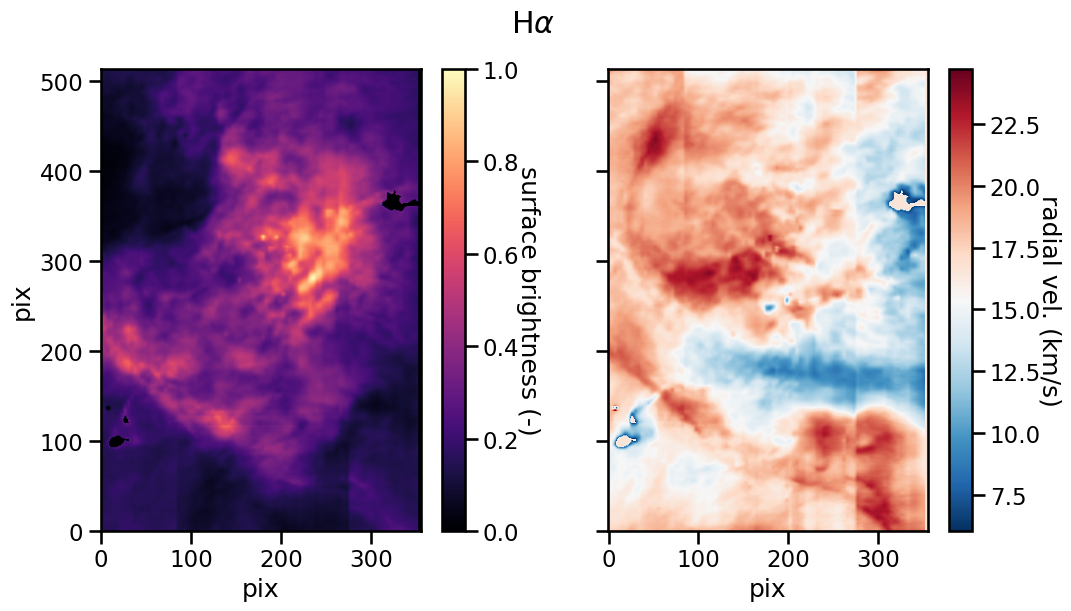

In [6]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow(vv_post, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)

im = axx.imshow(sb_post, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

Text(0.5, 0.98, 'H$\\alpha$')

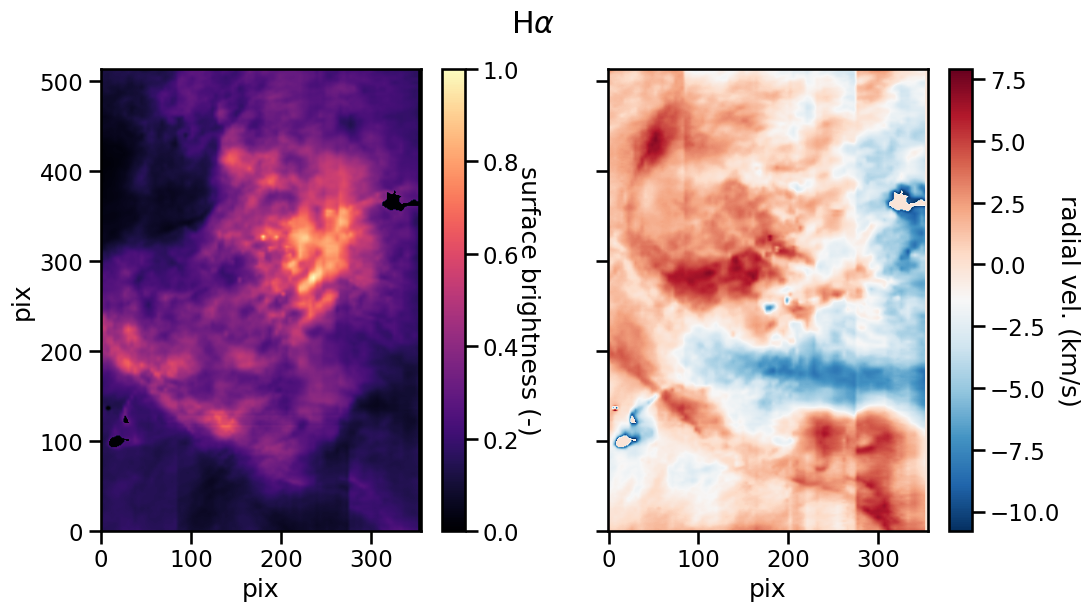

In [7]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow((vv_post-np.nanmean(vv_post)), **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)

im = axx.imshow(sb_post, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

In [8]:
values = np.asarray(vv_post, dtype=float).ravel()

stats = {
    "count": np.count_nonzero(~np.isnan(values)),
    "mean": np.nanmean(values),
    "median": np.nanmedian(values),
    "std": np.nanstd(values, ddof=1),
    "variance": np.nanvar(values, ddof=1),
    "min": np.nanmin(values),
    "max": np.nanmax(values),
    "range": np.nanmax(values) - np.nanmin(values),
    "missing": np.count_nonzero(np.isnan(values)),
}

print(stats)

{'count': 182984, 'mean': 16.820115160544447, 'median': 17.176166534423828, 'std': 2.932090181946654, 'variance': 8.597152835067963, 'min': 6.030075550079346, 'max': 24.722612380981445, 'range': 18.6925368309021, 'missing': 0}


Text(0.5, 1.0, 'Moment 1')

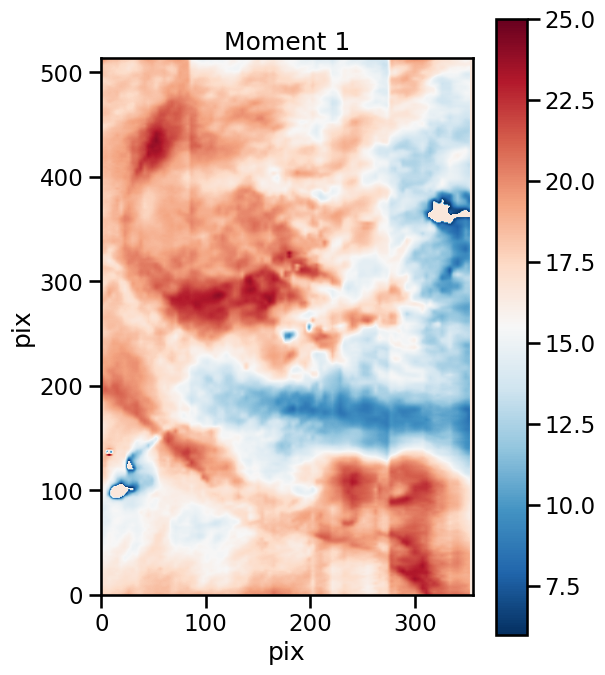

In [38]:
fig, (ax) = plt.subplots(
    1,
    1,
    sharey=False,
    figsize=(6, 8),
)

imshow_kwds = dict(origin="lower", cmap="RdBu_r")

im = ax.imshow(vv_post,
               vmin = 6,
               vmax = 25,**imshow_kwds)
im.cmap.set_bad(color='lime')

cbar = fig.colorbar(im, ax=[ax])
#cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
ax.set_title("Moment 1")

# PhD

In [10]:
name = 'KPech-Orion-H'

In [11]:
import json
import numpy as np
from pathlib import Path

file_path = Path("observations") / f"{name}-m.json"

with file_path.open("r", encoding="utf-8") as file:
    data = json.load(file)

sb_phd = np.asarray(data["sb"])
vv_phd = np.asarray(data["vv"])
#ss = np.array(data["ss"])



Text(0.5, 0.98, 'H$\\alpha$')

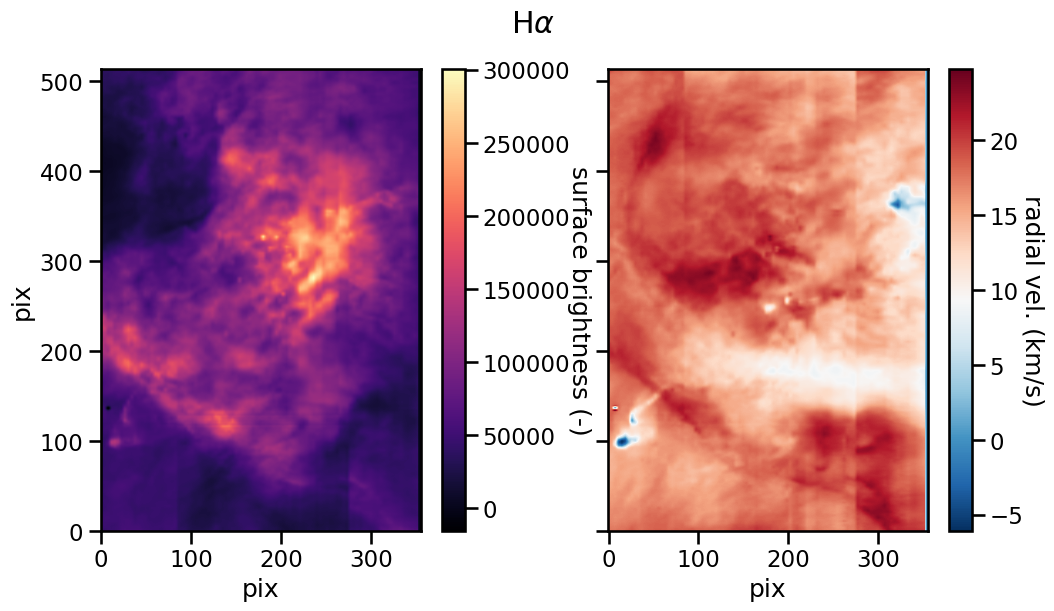

In [12]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow(vv_phd,
          #     vmin = 6,
          #     vmax = 25,
               **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)
im.cmap.set_bad(color='lime')

im = axx.imshow(sb_phd, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

In [13]:
values = np.asarray(vv_phd, dtype=float).ravel()

stats = {
    "count": np.count_nonzero(~np.isnan(values)),
    "mean": np.nanmean(values),
    "median": np.nanmedian(values),
    "std": np.nanstd(values, ddof=1),
    "variance": np.nanvar(values, ddof=1),
    "min": np.nanmin(values),
    "max": np.nanmax(values),
    "range": np.nanmax(values) - np.nanmin(values),
    "missing": np.count_nonzero(np.isnan(values)),
}

print(stats)

{'count': 182984, 'mean': 16.587718401502084, 'median': 17.176166534423828, 'std': 3.5216095812591868, 'variance': 12.401734042816503, 'min': -6.101345539093018, 'max': 24.722612380981445, 'range': 30.823957920074463, 'missing': 0}


In [14]:
## Replace spurious values in the arrays
m = ~np.isfinite(sb_phd*vv_phd) | (sb_phd < 0.0)

sb_phd[m] = 0.0
vv_phd[m] = np.nanmean(vv_phd)
#ss[m] = 0.0
sb_phd /= sb_phd.max()

good = (~m) & (sb_phd > 0.001)

Text(0.5, 0.98, 'H$\\alpha$')

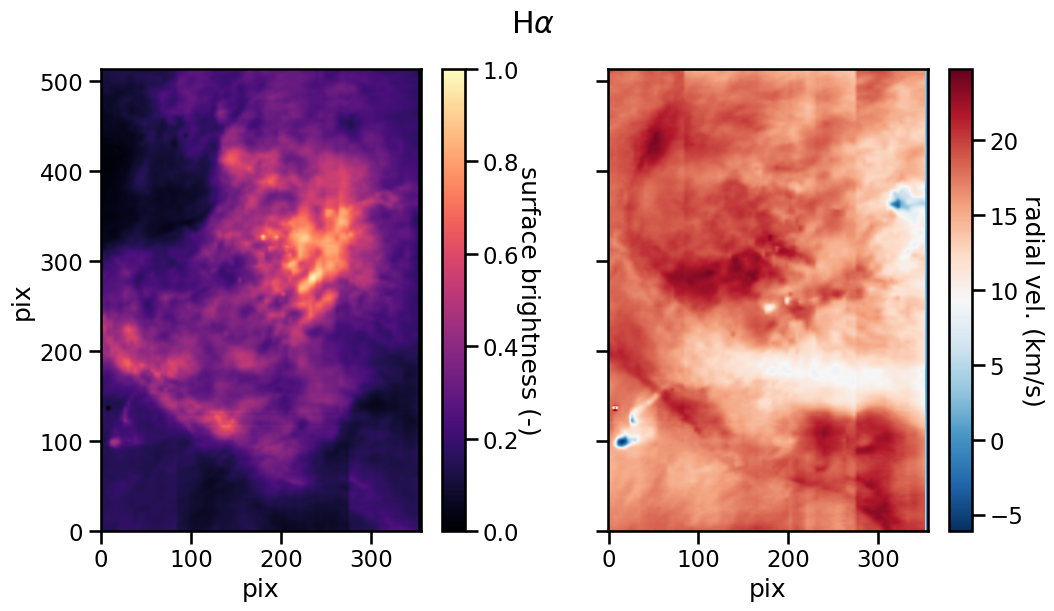

In [15]:
fig, (axx, ax) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(12, 6),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")

im = ax.imshow(vv_phd,
               #vmin = 6,
               #vmax = 25,
               **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("radial vel. (km/s)", rotation=270, labelpad=15)
im.cmap.set_bad(color='lime')

im = axx.imshow(sb_phd, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("surface brightness (-)", rotation=270, labelpad=15)
ax.set_xlabel('pix')
axx.set_xlabel('pix')
axx.set_ylabel('pix')

fig.suptitle(line)

In [16]:
#mu = vv.mean()
#vv_phd = np.where(good, vv_phd, mu)     

In [17]:
values = np.asarray(vv_phd, dtype=float).ravel()

stats = {
    "count": np.count_nonzero(~np.isnan(values)),
    "mean": np.nanmean(values),
    "median": np.nanmedian(values),
    "std": np.nanstd(values, ddof=1),
    "variance": np.nanvar(values, ddof=1),
    "min": np.nanmin(values),
    "max": np.nanmax(values),
    "range": np.nanmax(values) - np.nanmin(values),
    "missing": np.count_nonzero(np.isnan(values)),
}

print(stats)

{'count': 182984, 'mean': 16.588086176562616, 'median': 17.176166534423828, 'std': 3.5209084297891238, 'variance': 12.396796170960112, 'min': -6.101345539093018, 'max': 24.722612380981445, 'range': 30.823957920074463, 'missing': 0}


Text(0.5, 1.0, 'Moment 1')

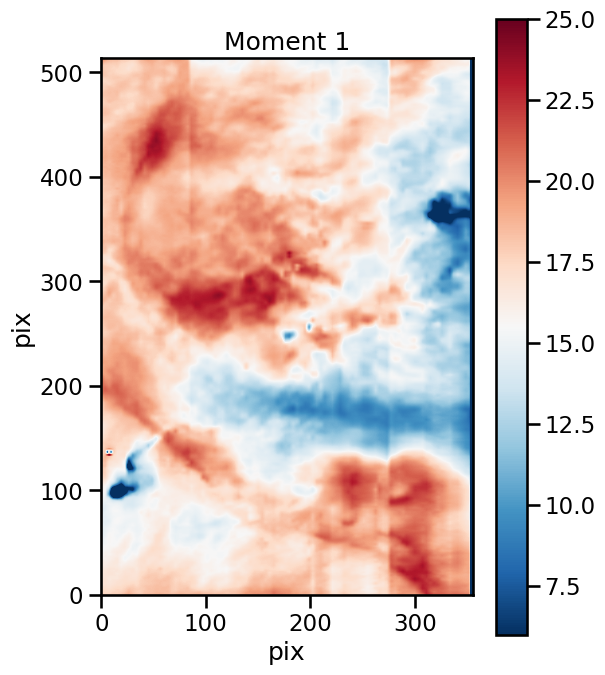

In [18]:
fig, (ax) = plt.subplots(
    1,
    1,
    sharey=False,
    figsize=(6, 8),
)

imshow_kwds = dict(origin="lower", cmap="RdBu_r")

im = ax.imshow(vv_phd,
               vmin = 6,
               vmax = 25,**imshow_kwds)
im.cmap.set_bad(color='lime')

cbar = fig.colorbar(im, ax=[ax])
#cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
ax.set_title("Moment 1")

In [ ]:
trim = (slice(0, 513), slice(0, 350))

Text(0.5, 1.0, 'Moment 1')

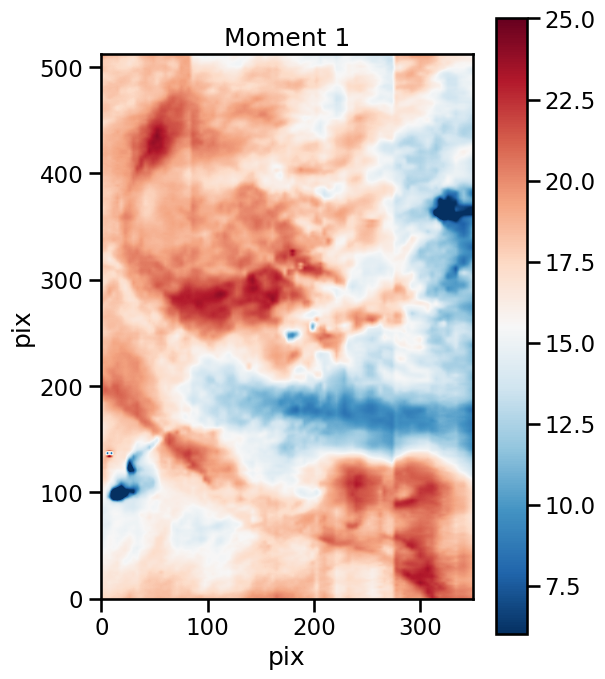

In [51]:
fig, (ax) = plt.subplots(
    1,
    1,
    sharey=False,
    figsize=(6, 8),
)

imshow_kwds = dict(origin="lower", cmap="RdBu_r")

im = ax.imshow(vv_phd[trim],
               vmin = 6,
               vmax = 25,**imshow_kwds)
im.cmap.set_bad(color='lime')

cbar = fig.colorbar(im, ax=[ax])
#cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
ax.set_title("Moment 1")

# Comparison

In [42]:
diff_mat = vv_post-vv_phd

Text(0.5, 1.0, 'Moment 1')

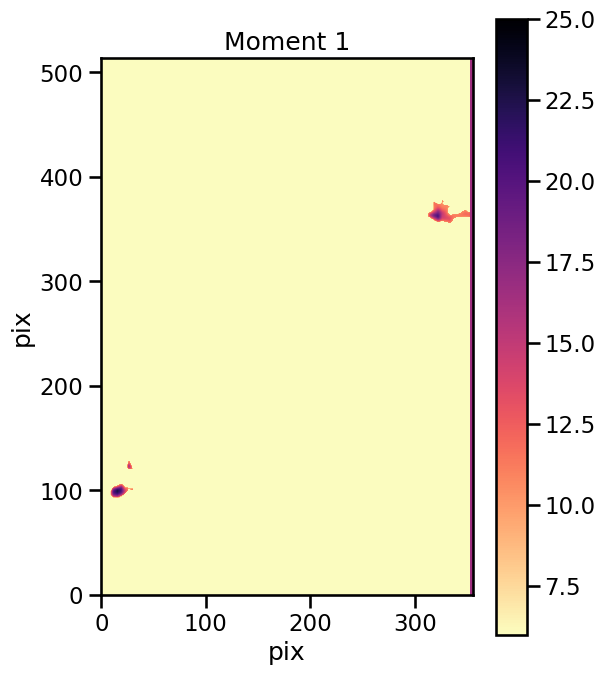

In [43]:
fig, (ax) = plt.subplots(
    1,
    1,
    sharey=False,
    figsize=(6, 8),
)

imshow_kwds = dict(origin="lower", cmap="magma_r")

im = ax.imshow(diff_mat ,
               vmin = 6,
               vmax = 25,**imshow_kwds)
im.cmap.set_bad(color='lime')

cbar = fig.colorbar(im, ax=[ax])
#cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
ax.set_title("Moment 1")

In [44]:
diff_mat 

array([[16.58808618,  0.        ,  0.        , ..., 16.58808618,
        16.58808618, 16.58808618],
       [16.58808618,  0.        ,  0.        , ..., 16.58808618,
        16.58808618, 16.58808618],
       [16.58808618,  0.        ,  0.        , ..., 16.58808618,
        16.58808618, 16.58808618],
       ...,
       [16.58808618,  0.        ,  0.        , ..., 16.58808618,
        16.58808618, 16.58808618],
       [16.58808618,  0.        ,  0.        , ..., 16.58808618,
        16.58808618, 16.58808618],
       [16.58808618,  0.        ,  0.        , ..., 16.58808618,
        16.58808618, 16.58808618]])

In [45]:
values = np.asarray(diff_mat , dtype=float).ravel()

stats = {
    "count": np.count_nonzero(~np.isnan(values)),
    "mean": np.nanmean(values),
    "median": np.nanmedian(values),
    "std": np.nanstd(values, ddof=1),
    "variance": np.nanvar(values, ddof=1),
    "min": np.nanmin(values),
    "max": np.nanmax(values),
    "range": np.nanmax(values) - np.nanmin(values),
    "missing": np.count_nonzero(np.isnan(values)),
}

print(stats)

{'count': 182984, 'mean': 0.23202898398183258, 'median': 0.0, 'std': 1.921449413498772, 'variance': 3.6919678486347753, 'min': 0.0, 'max': 22.689431715655633, 'range': 22.689431715655633, 'missing': 0}


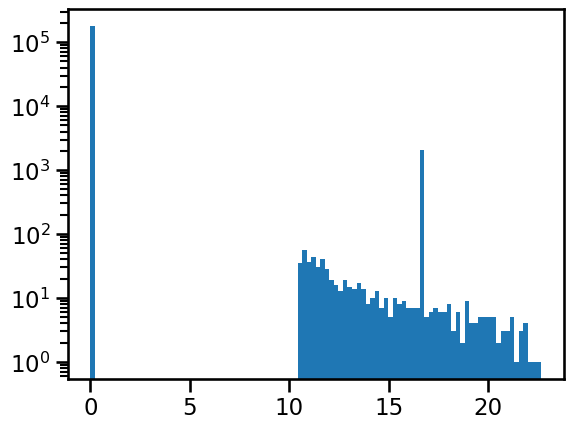

In [49]:
fig, ax = plt.subplots()
plt.hist(diff_mat [np.isfinite(diff_mat )& (np.abs(diff_mat)  < 150)] , bins=100)
ax.set_yscale("log")

# B(r)

In [23]:
name = 'KPech-Orion-H'

file_path = Path("observations") / f"sf-{name}.json"

with file_path.open("r", encoding="utf-8") as file:
    data_in = json.load(file)


mask_phd = np.array(data_in["SF"]["N pairs"]) > 0
B_phd = np.array(data_in["b2"])[mask_phd]
r_phd = np.array(data_in["s"])[mask_phd]
pc = np.array(data_in["pc"])
#pix = np.array(data_in["pix"])
#box_size = np.array(data_in["box_size"])
#pc_per_arcsec = pc

In [24]:
from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
data_in = t.to_pandas()


mask_post     = np.array(data_in["N pairs"]) > 0
B_post        = np.array(data_in['Unweighted B(r)'])[mask_post]
r_post        = np.array(10 ** np.array(data_in['log10 r'])* pix * pc)[mask_post]



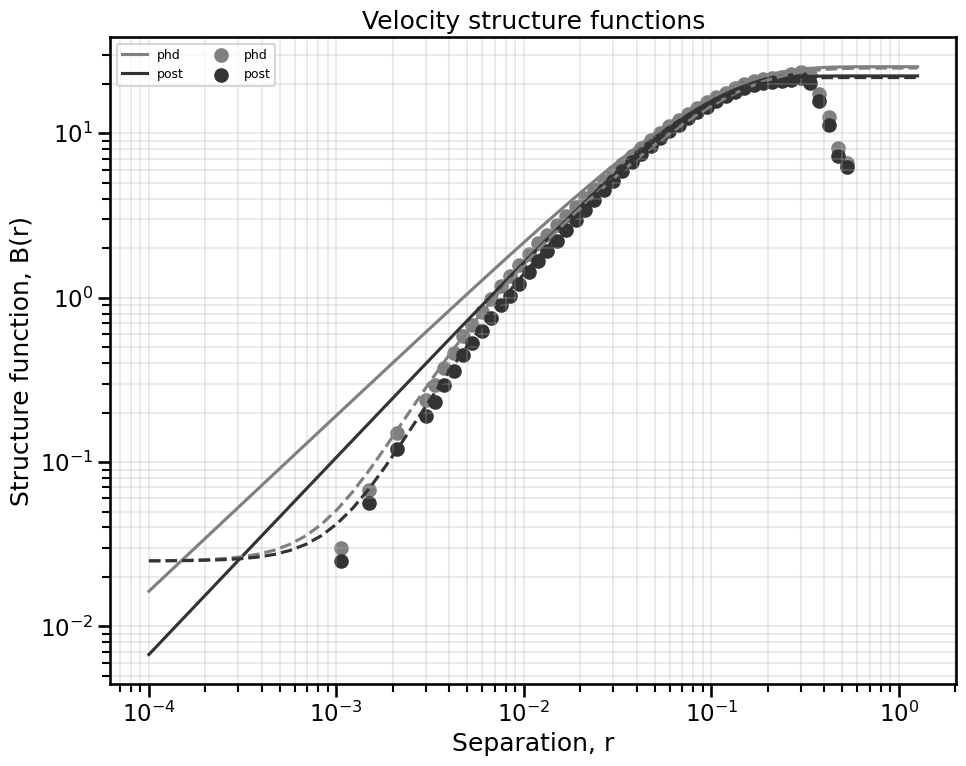

In [25]:
fig, ax = plt.subplots(figsize=(10, 8))

rgrid = np.logspace(-4, .1)
ax.plot(rgrid, bfunc.bfunc00s(rgrid, 0.0679, 12.67, 1.07), color="0.5", label = 'phd')
ax.plot(rgrid, bfunc.bfunc00s(rgrid, 0.063, 11.14, 1.2), color="0.2", label = 'post')

ax.plot(rgrid, bfunc.bfunc03s(rgrid, 0.079, 12.67, 1.07, 0.0015, 0.025), color="0.5",linestyle="--")
ax.plot(rgrid, bfunc.bfunc03s(rgrid, 0.063, 11.14, 1.2, 0.0015, 0.025), color="0.2",linestyle="--")

ax.scatter(r_phd,B_phd, color="0.5", label = 'phd')
ax.scatter(r_post ,B_post , color="0.2", label = 'post')

ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9, ncols=2)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="Separation, r",
    ylabel="Structure function, B(r)",
    title="Velocity structure functions",
)


fig.tight_layout()
plt.show()

<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:20: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_8716\530128966.py:20: SyntaxWarning: invalid escape sequence '\s'
  ylabel="Norm. Structure function, B(r)/$\sigma^2$",


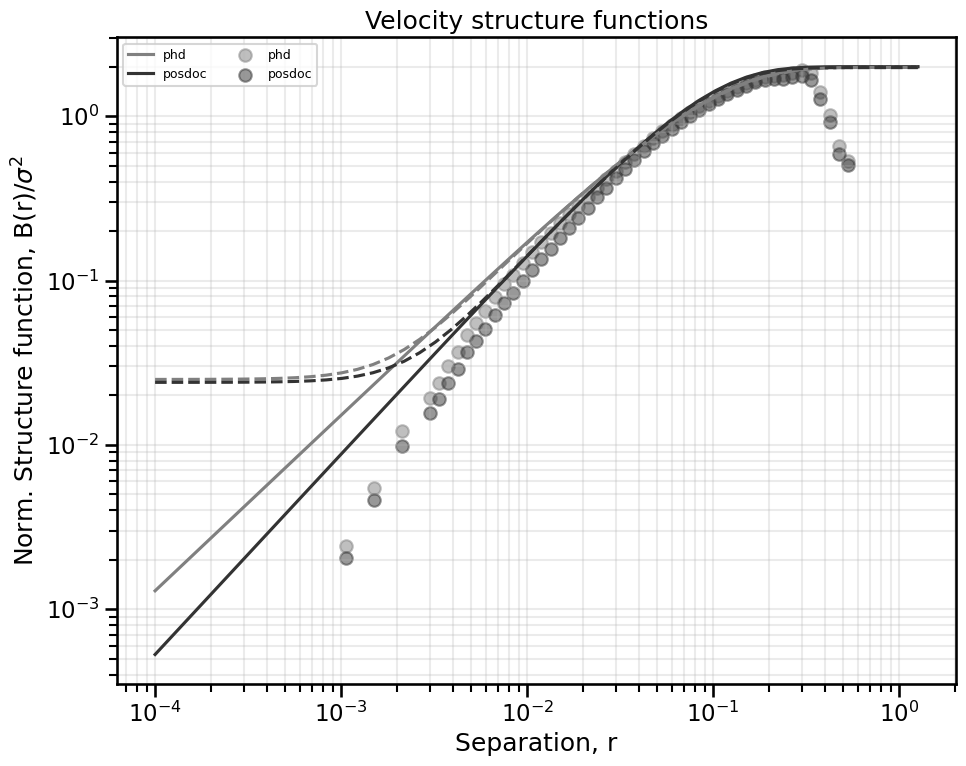

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

rgrid = np.logspace(-4, .1)
ax.plot(rgrid, bfunc.bfunc00s(rgrid, 0.0679, 1, 1.07), color="0.5", label = 'phd')
ax.plot(rgrid, bfunc.bfunc00s(rgrid, 0.0633, 1, 1.22), color="0.2", label = 'posdoc')

ax.plot(rgrid, bfunc.bfunc03s(rgrid, 0.0679, 1, 1.07, 0.0015, 0.025), color="0.5",linestyle="--")
ax.plot(rgrid, bfunc.bfunc03s(rgrid, 0.0633, 1, 1.22, 0.00154, 0.024), color="0.2",linestyle="--")

ax.scatter(r_phd,B_phd/3.52**2, color="0.5", label = 'phd', alpha = 0.5)
ax.scatter(r_post,B_post/3.5**2, color="0.2", label = 'posdoc', alpha = 0.5)

ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9, ncols=2)

ax.set(
    xscale="log",
    yscale="log",
    xlabel="Separation, r",
    ylabel="Norm. Structure function, B(r)/$\sigma^2$",
    title="Velocity structure functions",
)


fig.tight_layout()
plt.show()

Recomputing B(r)

In [57]:
rslt_trim    = strucfunc.strucfunc_numba_parallel(vv_phd[trim], wmap=sb_phd[trim], dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\structure_function_analysis\KPNO_orion\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\VIENTO\structure_function_analysis\KPNO_orion\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


In [58]:
output_path = "rslt_trim.pkl"

with open(output_path, "wb") as file:
    pickle.dump(rslt_trim, file)

In [59]:

import numpy as np

runs = {
    "trim": {
        "sb": sb_phd[trim],
        "velocity": vv_phd[trim],
        "result": rslt_trim,
    },
    "phd": {
        "sb": sb_phd,
        "velocity": vv_phd,
        "result": rslt_phd,
    },
    "posdoc": {
        "sb": sb_post,
        "velocity": vv_post,
        "result": rslt_posdoc,}
}

results = {}

for name, run in runs.items():
    velocity = np.asarray(run["velocity"], dtype=float)
    weights = np.asarray(run["sb"], dtype=float)
    rslt = run["result"]

    # Handle a one-pixel larger weight map
    if weights.shape == (
        velocity.shape[0] + 1,
        velocity.shape[1] + 1,
    ):
        weights = weights[:-1, :-1]

    # Stop for any other mismatch
    if velocity.shape != weights.shape:
        raise ValueError(
            f"{name}: velocity shape {velocity.shape} "
            f"does not match weight shape {weights.shape}"
        )

    valid_velocity = np.isfinite(velocity)

    valid_weighted = (
        np.isfinite(velocity)
        & np.isfinite(weights)
        & (weights > 0)
    )

    if not np.any(valid_velocity):
        raise ValueError(f"{name}: no finite velocity values")

    if not np.any(valid_weighted):
        raise ValueError(
            f"{name}: no valid velocity-weight pairs"
        )

    mean_velocity = np.mean(velocity[valid_velocity])
    sigma2 = np.var(velocity[valid_velocity])

    weighted_mean = np.average(
        velocity[valid_weighted],
        weights=weights[valid_weighted],
    )

    weighted_sigma2 = np.average(
        (velocity[valid_weighted] - weighted_mean) ** 2,
        weights=weights[valid_weighted],
    )

    rslt["Unweighted mean velocity"] = mean_velocity
    rslt["Unweighted sigma^2"] = sigma2
    rslt["Weighted mean velocity"] = weighted_mean
    rslt["Weighted sigma^2"] = weighted_sigma2

    b2 = np.asarray(rslt["Unweighted B(r)"], dtype=float)
    b2w = np.asarray(rslt["Weighted B(r)"], dtype=float)
    separation = (
        10 ** np.asarray(rslt["log10 r"], dtype=float)
        * data["pix"]
        * data["pc"]
    )

    results[name] = {
        "rslt": rslt,
        "b2": b2,
        "b2_error": 0.1 * b2,
        "b2_weighted": b2w,
        "b2_weighted_error": 0.1 * b2w,
        "separation": separation,
        "separation_error": 0.1 * separation,
        "mean_velocity": mean_velocity,
        "weighted_mean_velocity": weighted_mean,
        "sigma2": sigma2,
        "sigma": np.sqrt(sigma2),
        "sigma2_weighted": weighted_sigma2,
        "sigma_weighted": np.sqrt(weighted_sigma2),
    }

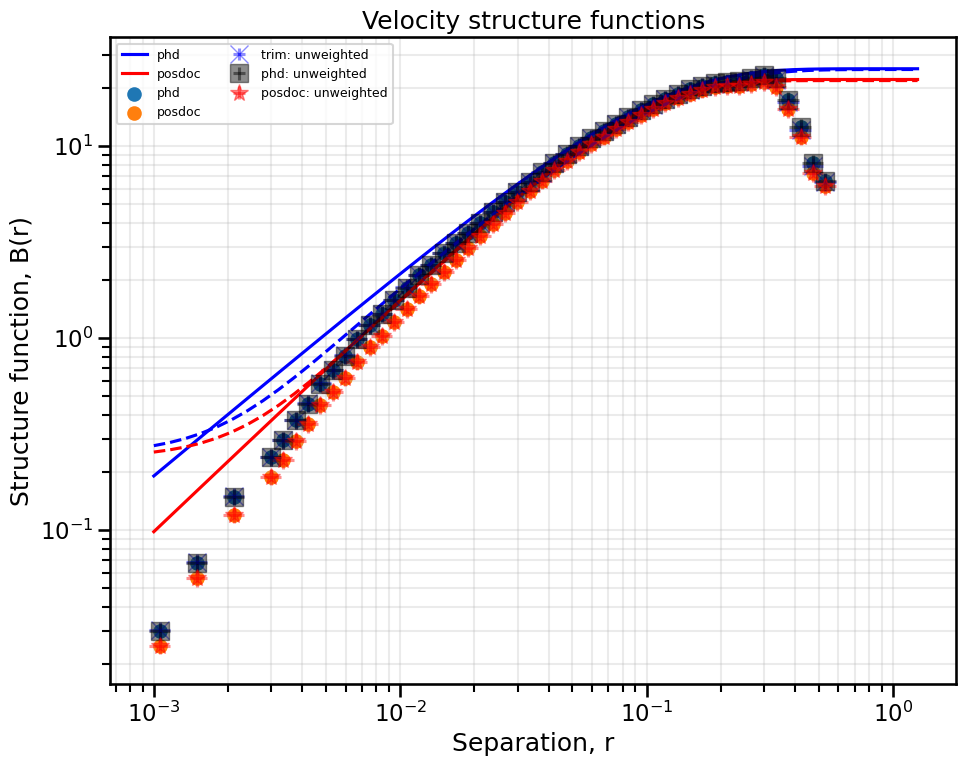

In [60]:
fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    "trim": "blue",
    "phd": "black",
    "posdoc": "red",
}

markers = {
    "trim": "x",
    "phd": "s",
    "posdoc": "*",
}


for name, values in results.items():

    s = np.asarray(values["separation"], dtype=float)
    e_s = np.asarray(values["separation_error"], dtype=float)

    b2 = np.asarray(values["b2"], dtype=float)
    e_b2 = np.asarray(values["b2_error"], dtype=float)

 #   b2w = np.asarray(values["b2_weighted"], dtype=float)
 #   e_b2w = np.asarray(
 #       values["b2_weighted_error"],
 #       dtype=float,
 #   )

    color = colors.get(name)
    marker = markers.get(name)

    # Mask for unweighted values
    mask = (
        np.isfinite(s)
        & np.isfinite(e_s)
        & np.isfinite(b2)
        & np.isfinite(e_b2)
        & (s > 0)
        & (b2 > 0)
    )

    ax.errorbar(
        s[mask],
        b2[mask],
        xerr=e_s[mask],
        yerr=e_b2[mask],
        fmt=marker,
        markersize=13,
        alpha=0.45,
        color=color,
        label=f"{name}: unweighted",
    )

    # Mask for weighted values
    #mask_w = (
    #    np.isfinite(s)
    #    & np.isfinite(e_s)
    #    & np.isfinite(b2w)
    #    & np.isfinite(e_b2w)
    #    & (s > 0)
    #    & (b2w > 0)
    #)

   # ax.errorbar(
   #     s[mask_w],
   #     b2w[mask_w],
   #     xerr=e_s[mask_w],
   #     yerr=e_b2w[mask_w],
   #     fmt="x",
   #     markersize=6,
   #     alpha=0.75,
   #     color=color,
   #     label=f"{name}: weighted",
   # )

ax.set(
    xscale="log",
    yscale="log",
    xlabel="Separation, r",
    ylabel="Structure function, B(r)",
    title="Velocity structure functions",
)

rgrid = np.logspace(-3, .1)
ax.plot(rgrid, bfunc.bfunc00s(rgrid, 0.0679, 12.67, 1.07), color="blue", label = 'phd')
ax.plot(rgrid, bfunc.bfunc00s(rgrid, 0.063, 11.14, 1.22), color="red", label = 'posdoc')

ax.plot(rgrid, bfunc.bfunc03s(rgrid, 0.079, 12.67, 1.07, 0.0015, 0.25), color="blue",linestyle="--")
ax.plot(rgrid, bfunc.bfunc03s(rgrid, 0.063, 11.14, 1.22, 0.0015, 0.24), color="red",linestyle="--")

ax.scatter(r_phd,B_phd, label = 'phd')
ax.scatter(r_post,B_post, label = 'posdoc')
#ax.scatter(results['posdoc']['separation'][masl],results['posdoc']['b2'][masl], label = 'posdoc x')


ax.grid(True, which="both", alpha=0.25)
ax.legend(fontsize=9, ncols=2)

fig.tight_layout()
plt.show()

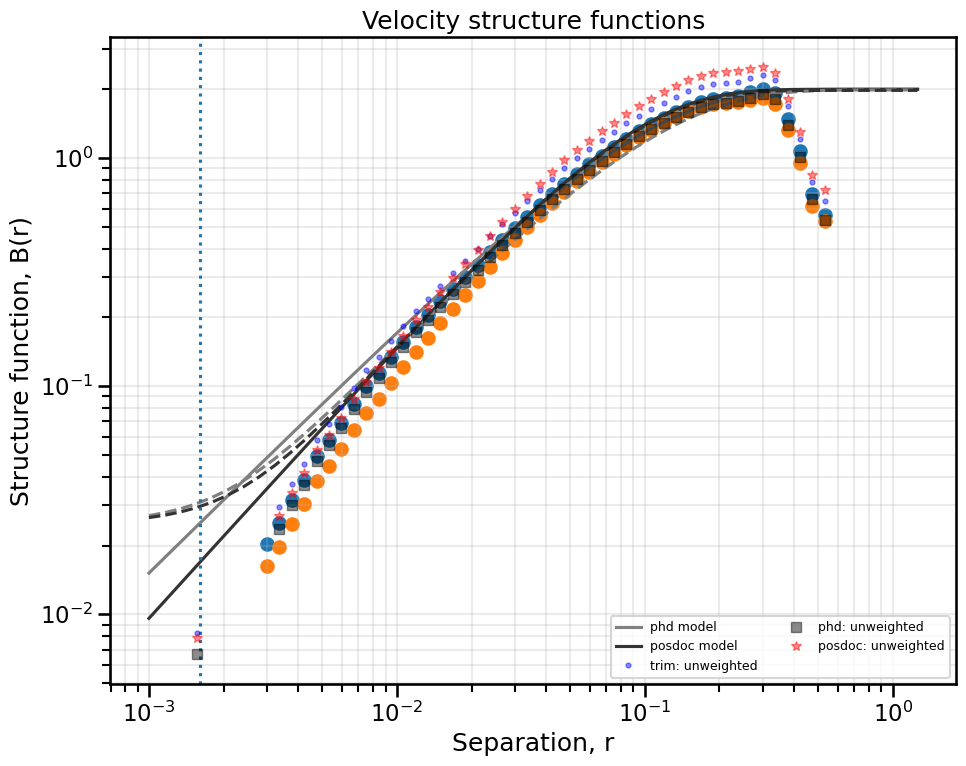

In [62]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 8))

colors = {
    "trim": "blue",
    "phd": "black",
    "posdoc": "red",
}

markers = {
    "trim": ".",
    "phd": "s",
    "posdoc": "*",
}

K = 3

for name, values in results.items():

    s = np.asarray(values["separation"], dtype=float)
    e_s = np.asarray(values["separation_error"], dtype=float)

    b2 = np.asarray(values["b2"], dtype=float)
    e_b2 = np.asarray(values["b2_error"], dtype=float)

    sigma2 = np.asarray(values["sigma2"], dtype=float)
    
    color = colors.get(name)
    marker = markers.get(name)

    # Keep finite, positive values for logarithmic axes
    mask = (
        np.isfinite(s)
        & np.isfinite(e_s)
        & np.isfinite(b2)
        & np.isfinite(e_b2)
        & (s > 0)
        & (b2 > 0)
    )

    # Apply the mask first
    r = s[mask].copy()
    B = b2[mask].copy()
    e_r = e_s[mask].copy()
    e_B = e_b2[mask].copy()

    # Combine the first K points into one point
    if len(r) > K:
        r[K] = np.mean(r[:K])
        B[K] = np.mean(B[:K])

        # Propagate independent errors for the mean
        e_r[K] = np.sqrt(np.sum(e_r[:K] ** 2)) / K
        e_B[K] = np.sqrt(np.sum(e_B[:K] ** 2)) / K

        # Remove the original first K points
        r = r[K:]
        B = B[K:]/sigma2
        e_r = e_r[K:]
        e_B = e_B[K:]

    ax.errorbar(
        r,
        B,
#        xerr=e_r,
#        yerr=e_B,
        fmt=marker,
        markersize=7,
        alpha=0.45,
        color=color,
        label=f"{name}: unweighted",
    )

ax.set(
    xscale="log",
    yscale="log",
    xlabel="Separation, r",
    ylabel="Structure function, B(r)",
    title="Velocity structure functions",
)

rgrid = np.logspace(-3, 0.1)

ax.plot(
    rgrid,
    bfunc.bfunc00s(rgrid, 0.0679, 1, 1.07),
    color="0.5",
    label="phd model",
)

ax.plot(
    rgrid,
    bfunc.bfunc00s(rgrid, 0.063, 1, 1.2),
    color="0.2",
    label="posdoc model",
)

ax.plot(
    rgrid,
    bfunc.bfunc03s(
        rgrid, 0.079, 1, 1.07, 0.0015, 0.025
    ),
    color="0.5",
    linestyle="--",
)

ax.plot(
    rgrid,
    bfunc.bfunc03s(
        rgrid, 0.063, 1, 1.2, 0.0015, 0.025
    ),
    color="0.2",
    linestyle="--",
)

ax.axvline(0.0016, ls=':')

ax.grid(True, which="both", alpha=0.25)
ax.scatter(r_phd[K:],B_phd[K:]/3.43**2)
ax.scatter(r_post[K:],B_post[K:]/3.43**2)

ax.legend(fontsize=9, ncols=2)

fig.tight_layout()
plt.show()